# Figure 10: Beta and Gamma Rhythms Bidirectionally Modulate Clustered Synaptic Drive in a Location-Dependent Manner

This notebook analyzes how beta and gamma rhythmic inhibition affect the responsiveness of pyramidal neurons to clustered excitatory synaptic inputs at different dendritic locations. Based on Headley et al. (2026), *Spatially targeted inhibitory rhythms differentially affect neuronal integration*, eLife.

## Biological Context:

**Functional clustering:** Experimental evidence shows that synapses cluster on dendritic branches such that functional presynaptic cell assemblies activate the same branch within 5-10 µm. This clustering facilitates dendritic integration and can drive dendritic spikes.

**Location matters:** The dendrites receive inputs from different cortical layers:
- **Distal apical dendrites (tuft):** Long-range inputs from higher cortical areas (feedback/top-down)
- **Proximal basal dendrites:** Local inputs from layer 5 pyramidal neurons (lateral connectivity)


## Key Findings:

3. **Spatial specificity** (apical vs. basal location)

**Beta rhythms (16 Hz, distal dendrites):**2. **Phase dependence** (peak vs. trough modulation)

- **Bidirectionally modulate** transmission from distal (apical) clustered inputs1. **Strength of coupling** (area under cross-correlation peak)

  - Enhance during trough phase (low inhibition)Phase-stratified cross-correlations between clustered presynaptic spikes and somatic action potentials reveal:

  - Suppress during peak phase (high inhibition)

- **Suppress** transmission from proximal (basal) clustered inputs## Analyses:

- Effect relative to arhythmic (Poisson) inhibition baseline

4. **Coactivation:** 40 presynaptic spike trains with ±2 ms jitter from single Poisson process

**Gamma rhythms (64 Hz, perisomatic):**3. **Synaptic density:** 1.3 synapses/µm over 140 µm (187 total synapses)

- **Bidirectionally modulate** transmission from proximal (basal) clustered inputs2. **Clustered excitatory inputs** at distal apical dendrites (near nexus) or proximal basal dendrites

  - Enhance during trough phase1. **Rhythmic inhibition** (16 Hz distal or 64 Hz perisomatic) or Poisson control

  - Suppress during peak phaseThe simulations include:

- **Suppress or barely affect** transmission from distal (apical) clustered inputs

## Simulation Details:

**Counterposed modulation:** Beta and gamma rhythms regulate neuronal sensitivity to afferents throughout the dendritic tree in a **location-dependent manner** that is opposite/complementary:

- Beta gates distal inputs (feedback/top-down signals)- Gamma gates proximal inputs (local/feedforward signals)

In [12]:
import sys
import os
sys.path.append('..') # have to do this for relative imports in jupyter
import numpy as np
import pandas as pd
import scipy as sp
import matplotlib.pyplot as plt
import matplotlib.colors as colors
from sklearn.linear_model import LogisticRegression
from src.cc_presyn_phdep_files import cc_presyn_phdep_files
from src.load_spike_h5 import load_spike_h5
from src.load_spike_aux_h5 import load_spike_aux_h5
from src.cc_ptpt import cc_ptpt

## 1.0 Analysis Parameters

**Spurious periodicities:** Since both presynaptic spikes and action potentials have inherent periodicities from the rhythmic inhibition, these must be corrected by converting to frequency domain, setting coefficients at the inhibitory modulation frequency to 0, and converting back (see Methods).

### 1.1 Simulation Constants and Cross-Correlation Windows

Cross-correlation analysis measures the temporal coupling between clustered presynaptic spike times and somatic action potentials. The analysis window captures the synaptic-to-spike delay and reveals how rhythmic inhibition modulates this coupling in a phase-dependent manner.

In [13]:
samps_per_ms = 10 # samples per millisecond
fs = 10000 # sampling frequency
sim_win = [0, 9000000] # beginning and start points of simulation in samples
cc_bin = samps_per_ms * 1 # bin size for cross-correlation in samples
cc_win = [-499, 500] # number of lags for cross-correlation 

### 1.2 Simulation Files

- Jitter: ±2 ms from single Poisson process (simulates coordinated assembly activity)

These files contain simulations with functional clustering of excitatory synapses:- Coactivation: 40 presynaptic neurons, each driving ~4.6 synapses

- Density: 1.3 synapses/µm (similar to in vivo functional clusters)

**Clustered input locations:****Synaptic clustering parameters:**

- **conc_apical:** 140 µm at apical nexus (bifurcation toward tuft)

- **conc_basal:** 140 µm across 3 basal dendrites directly connected to soma (40-50 µm each)- **poiss:** Arhythmic Poisson inhibition (baseline)

- **diff:** Diffuse (control) - inputs distributed throughout dendrites- **64 Hz:** Gamma rhythm at perisomatic compartments (<100 µm from soma)

- **16 Hz:** Beta rhythm at distal dendrites (>100 µm from soma)
**Rhythmic inhibition conditions:**

In [14]:
# locate simulation files
dir_list = [{'RootDir': 'D:\\DendCompOscPublic\\output_clust_16Hz_conc_apical\\3groups',
             'InhibType': '16', 
             'ExcType': 'conc', 
             'ExcLoc': 'apical'},
            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_16Hz_conc_basal\\3groups',
             'InhibType': '16', 
             'ExcType': 'conc', 
             'ExcLoc': 'basal'},
            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_16Hz_diff\\long',
             'InhibType': '16', 
             'ExcType': 'diff', 
             'ExcLoc': 'apical'},

            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_64Hz_conc_apical\\3groups',
             'InhibType': '64', 
             'ExcType': 'conc', 
             'ExcLoc': 'apical'},
            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_64Hz_conc_basal\\3groups',
             'InhibType': '64', 
             'ExcType': 'conc', 
             'ExcLoc': 'basal'},
            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_64Hz_diff\\long',
             'InhibType': '64', 
             'ExcType': 'diff', 
             'ExcLoc': 'apical'},

            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_poiss_conc_apical\\3groups',
             'InhibType': 'poiss', 
             'ExcType': 'conc', 
             'ExcLoc': 'apical'},
            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_poiss_conc_basal\\3groups',
             'InhibType': 'poiss', 
             'ExcType': 'conc', 
             'ExcLoc': 'basal'},
            {'RootDir': 'D:\\DendCompOscPublic\\output_clust_poiss_diff\\long',
             'InhibType': 'poiss', 
             'ExcType': 'diff', 
             'ExcLoc': 'apical'}]


sim_df = pd.DataFrame(dir_list)

### 1.3 Generate Inhibitory Rhythm Phase Time Series

Sinusoidal modulation of inhibitory drive creates phase labels for stratifying cross-correlation analysis. Events occurring during positive phase (above mean) are labeled as 'peak' phase, while those during negative phase are labeled as 'trough' phase. This allows separate measurement of synaptic transmission strength during high vs. low inhibition periods.

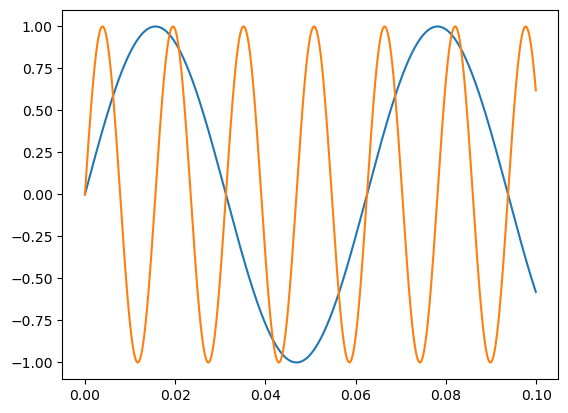

In [15]:
# generate phase time series for inhibitory afferents
t_ser = np.arange(sim_win[0], sim_win[1], 1) / fs # seconds
sin_16_ser = np.sin(t_ser*16*2*np.pi)
sin_64_ser = np.sin(t_ser*64*2*np.pi)

fig, ax = plt.subplots()
ax.plot(t_ser[0:1000],sin_16_ser[0:1000])
ax.plot(t_ser[0:1000],sin_64_ser[0:1000])
plt.show()

## 2.0 Phase-Stratified Cross-Correlation Analysis

This creates a **frequency-specific routing mechanism** where different rhythms gate different information streams based on their cortical origin and dendritic termination zone.

This analysis quantifies how rhythmic inhibition modulates the **conversion of clustered presynaptic activity into somatic action potentials**. 

- Gamma (perisomatic) → modulates feedforward/local signals arriving at basal dendrites

**Mechanisms revealed:**- Beta (distal dendrites) → modulates feedback/top-down signals arriving at apical tuft

1. **Bidirectional modulation:** Enhanced transmission during trough, suppressed during peak**Interpretation:** The spatial specificity of these effects suggests that beta and gamma rhythms regulate different input pathways:

2. **Suppression only:** Reduced transmission during both phases relative to Poisson baseline
3. **No effect:** Transmission strength unchanged by rhythm

### 2.1 Calculate Phase-Stratified Cross-Correlations

The positive peak nearest zero lag represents the synaptic-to-spike coupling. Its **area under the curve** (integrated over zero-crossings) quantifies the strength of this coupling. Changes in peak area reveal how rhythmic inhibition modulates responsiveness to the clustered input.

The cross-correlation function measures the temporal relationship between clustered presynaptic spikes and somatic action potentials, separated by rhythm phase:**Peak identification:**



**For rhythmic conditions (16 Hz, 64 Hz):**- Serves as baseline for comparison

- Presynaptic spikes grouped by peak vs. trough phase of inhibitory rhythm- Single cross-correlogram (no phase separation)

- Separate cross-correlograms computed for each phase**For Poisson control:**

- Notch filter removes spurious periodicities at inhibition frequency
- Smoothing with 1 ms window reduces noise

In [16]:
def cc_func(sim_dir, inhib_type):
    # create full file path for presynaptic spike times and AP times, make OS independent
    presyn_file = os.path.join(sim_dir, 'exc_stim_aux_spikes2.h5')
    ap_file = os.path.join(sim_dir, 'spikes.h5')

    # calculate cross-correlation
    if inhib_type == '16':
        cc = cc_presyn_phdep_files(presyn_file, ap_file, sin_16_ser, cc_bin, cc_win, sm_win=1, notch_freq=16)
    elif inhib_type == '64':
        cc = cc_presyn_phdep_files(presyn_file, ap_file, sin_64_ser, cc_bin, cc_win, sm_win=1, notch_freq=64)
    elif inhib_type == 'poiss':
        spk_pts = load_spike_h5(ap_file)
        pre_pts = load_spike_aux_h5(presyn_file)
        cc = {'poiss': cc_ptpt(spk_pts, pre_pts, cc_bin, cc_win, 1)}
    return cc
    
# calculate cross-correlation for each simulation
sim_cc_df = sim_df.assign(AllCC = sim_df.apply(lambda x: cc_func(x['RootDir'], x['InhibType']), axis=1))

In [17]:
# breakout CC dictionaries
sim_cc_df = sim_cc_df.join(pd.DataFrame(sim_cc_df['AllCC'].tolist()))
sim_cc_df = pd.melt(sim_cc_df, id_vars=['RootDir', 'InhibType', 'ExcType', 'ExcLoc'],
                 value_vars=['t', 'p', 'poiss'], var_name='InhibPhase', value_name='CC')
sim_cc_df = sim_cc_df.dropna()
sim_cc_df = sim_cc_df.reset_index(drop=True)
sim_cc_df = sim_cc_df.join(pd.DataFrame(sim_cc_df['CC'].tolist()))
sim_cc_df.drop('CC', axis=1)

# smooth cross-correlations
def sm_func(x):
    sm_kern = np.hamming(3)
    x_sm = np.convolve(x, sm_kern/np.sum(sm_kern), mode='same')
    x_sm -= np.mean(x_sm)
    return x_sm

# smooth values_corr in sim_cc_df
sim_cc_df['values_corr_sm'] = sim_cc_df['values_corr'].apply(sm_func)

In [18]:
# group by excitatory input type
exc_df = sim_cc_df.groupby(['ExcType', 'ExcLoc'])

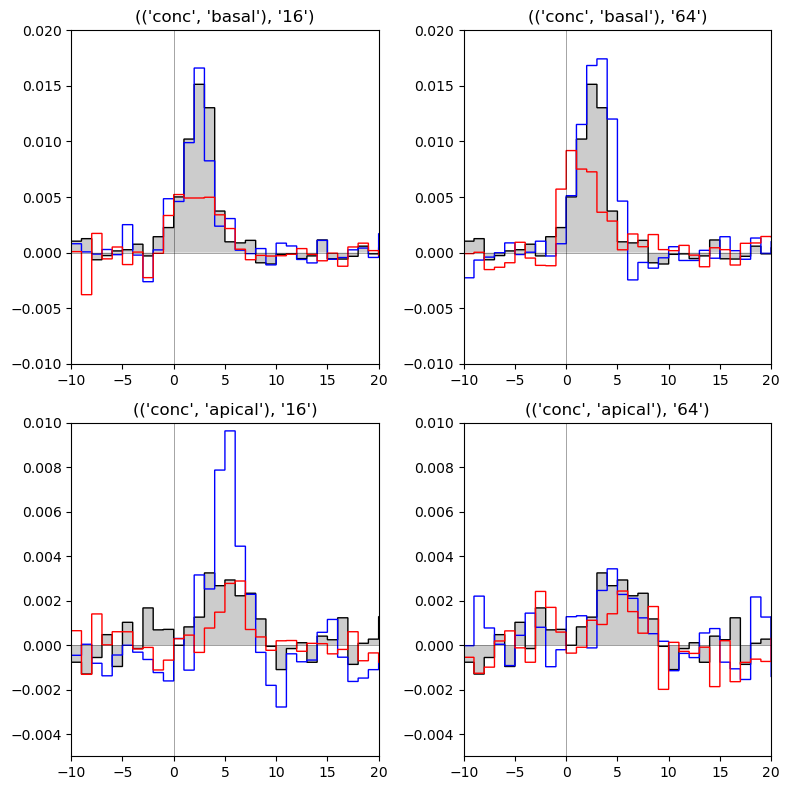

In [19]:
# plot corrected cross-correlations by excitatory input type
def plot_cc(sim_row, ax, **kwargs):
    ax.stairs(sim_row['values_corr_sm'].iloc[0][0:-1], sim_row['lags'].iloc[0], **kwargs)

def plot_exp(sim_set, exp_name, exp_freq, ax):
    plot_cc(sim_set[sim_set['InhibPhase']=='poiss'],ax, color=[0.8]*3, fill=True)
    plot_cc(sim_set[sim_set['InhibPhase']=='poiss'],ax, color='k')
    plot_cc(sim_set.loc[(sim_set['InhibPhase']=='t') & (sim_set['InhibType']==exp_freq)],ax, color='b')
    plot_cc(sim_set.loc[(sim_set['InhibPhase']=='p') & (sim_set['InhibType']==exp_freq)],ax, color='r')
    
    ax.set_title((exp_name, exp_freq))
    #ax.set_ylim(-0.01,0.015)
    ax.set_xlim(-10,20)
    # create grid only on origin
    ax.vlines(0, -0.01, 0.02, color='k', linewidth=0.5, alpha=0.5)
    ax.hlines(0, -10, 20, color='k', linewidth=0.5, alpha=0.5)


fig,ax = plt.subplots(2,2)
plot_exp(exc_df.get_group(('conc', 'basal')), ('conc', 'basal'), '16',ax[0,0])
ax[0,0].set_ylim(-0.01,0.02)
plot_exp(exc_df.get_group(('conc', 'basal')), ('conc', 'basal'), '64',ax[0,1])
ax[0,1].set_ylim(-0.01,0.02)
plot_exp(exc_df.get_group(('conc', 'apical')), ('conc', 'apical'), '16',ax[1,0])
ax[1,0].set_ylim(-0.005,0.01)
plot_exp(exc_df.get_group(('conc', 'apical')), ('conc', 'apical'), '64',ax[1,1])
ax[1,1].set_ylim(-0.005,0.01)
fig.set_size_inches(8, 8)
fig.tight_layout()

In [20]:
# define a function to calculate the area under a curve bordered by zero-crossings
# that encompasses a user specified position
def area_under_curve(x, ind):
    # find the zero-crossing before the index
    ind0 = np.where(np.diff(np.sign(x[0:ind])))[0]
    if len(ind0) == 0:
        ind0 = 0
    else:
        ind0 = ind0[-1]

    # find the zero-crossing after the index
    ind1 = np.where(np.diff(np.sign(x[ind:-1])))[0]

    if len(ind1) == 0:
        ind1 = len(x)
    else:
        ind1 = ind1[0] + ind
    
    # calculate the area under the curve
    area = np.trapz(x[ind0:ind1])

    return area

# identify the index overlapping with the cross-correlation peak
ind_peak = (-cc_win[0])+5

# calculate the area under the curve for each simulation
sim_cc_df['resp_area'] = sim_cc_df['values_corr_sm'].apply(lambda x: area_under_curve(x, ind_peak))

In [21]:
exc_df = sim_cc_df.groupby(['ExcType', 'ExcLoc'])[['resp_area', 'InhibType', 'InhibPhase']]
exc_df.get_group(('conc', 'basal'))

,resp_area,InhibType,InhibPhase
1,0.047066,16,t
4,0.057582,64,t
7,0.027835,16,p
10,0.040016,64,p
13,0.052098,poiss,poiss


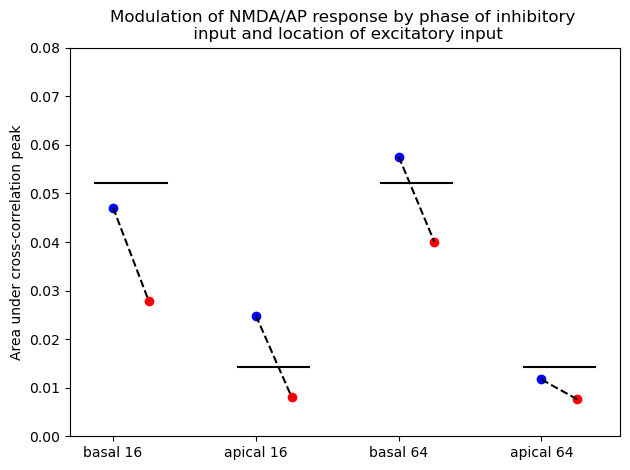

In [22]:
# group by excitatory input type

# plot cross-correlation strengths by excitatory input type and phase
def plot_exp_resp(sim_set, exp_freq, offset, ax):
    offset = offset*4
    poiss_resp = sim_set.loc[(sim_set['InhibPhase']=='poiss')]['resp_area'].iloc[0]
    t_resp = sim_set.loc[(sim_set['InhibPhase']=='t') & (sim_set['InhibType']==exp_freq)]['resp_area'].iloc[0]
    p_resp = sim_set.loc[(sim_set['InhibPhase']=='p') & (sim_set['InhibType']==exp_freq)]['resp_area'].iloc[0]

    ax.plot(offset+np.array([0.5,2.5]), [poiss_resp, poiss_resp], color='k')
    #ax.scatter(offset, poiss_resp, color='k')
    ax.plot(offset+np.array([1,2]), [t_resp, p_resp], color='k', linestyle='--')
    ax.scatter(offset+1, t_resp, color='b')
    ax.scatter(offset+2, p_resp, color='r')


fig,ax = plt.subplots()
plot_exp_resp(exc_df.get_group(('conc', 'basal')), '16', 0, ax)
plot_exp_resp(exc_df.get_group(('conc', 'apical')), '16', 1, ax)
plot_exp_resp(exc_df.get_group(('conc', 'basal')), '64', 2, ax)
plot_exp_resp(exc_df.get_group(('conc', 'apical')), '64', 3, ax)
ax.set_ylim([0,0.08])
ax.set_xticks([1,5,9,13])
ax.set_xticklabels(['basal 16', 'apical 16', 'basal 64', 'apical 64'])
ax.set_ylabel('Area under cross-correlation peak')
ax.set_title('Modulation of NMDA/AP response by phase of inhibitory \n input and location of excitatory input')
fig.tight_layout()